## ML&Fintech HW9 Chapter 8 Q8

Name: Alvin B. Lin\
ID: 112652040\
Date: 24/11/2025\
HW #: 9

8.In the lab, a classification tree was applied to the `Carseats` data set after converting `Sales` into a qualitative response variable. Now we will seek to predict `Sales` using regression trees and related approaches, treating the response as a quantitative variable.

In [2]:
from ISLP import load_data

Carseats = load_data('Carseats')

In [4]:
Carseats.head()

,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US
0,9.50,138,73,11,276,120,Bad,42,17,Yes,Yes
1,11.22,111,48,16,260,83,Good,65,10,Yes,Yes
2,10.06,113,35,10,269,80,Medium,59,12,Yes,Yes
3,7.40,117,100,4,466,97,Medium,55,14,Yes,Yes
4,4.15,141,64,3,340,128,Bad,38,13,Yes,No


In [6]:
import numpy as np
import pandas as pd

# convert 'Sales' to quantitative variable
Carseats['Sales'] = pd.to_numeric(Carseats['Sales'], errors='coerce')
Carseats = Carseats.dropna(subset=['Sales'])  # Drop rows where 'Sales' could not be converted

(a) Split the data set into a training set and a test set.

In [17]:
# do train test split
from sklearn.model_selection import train_test_split

# convert 'shelveloc' from categorical to dummy variables
# Carseats = pd.get_dummies(Carseats, columns=['ShelveLoc', 'Urban', 'US'], drop_first=True, dtype=int)
train_data, test_data = train_test_split(Carseats, test_size=0.3, random_state=42)
train_X = train_data.drop(columns=['Sales'])
train_y = train_data['Sales']
test_X = test_data.drop(columns=['Sales'])
test_y = test_data['Sales']

(b) Fit a regression tree to the training set. Plot the tree, and interpret the results. What test MSE do you obtain?

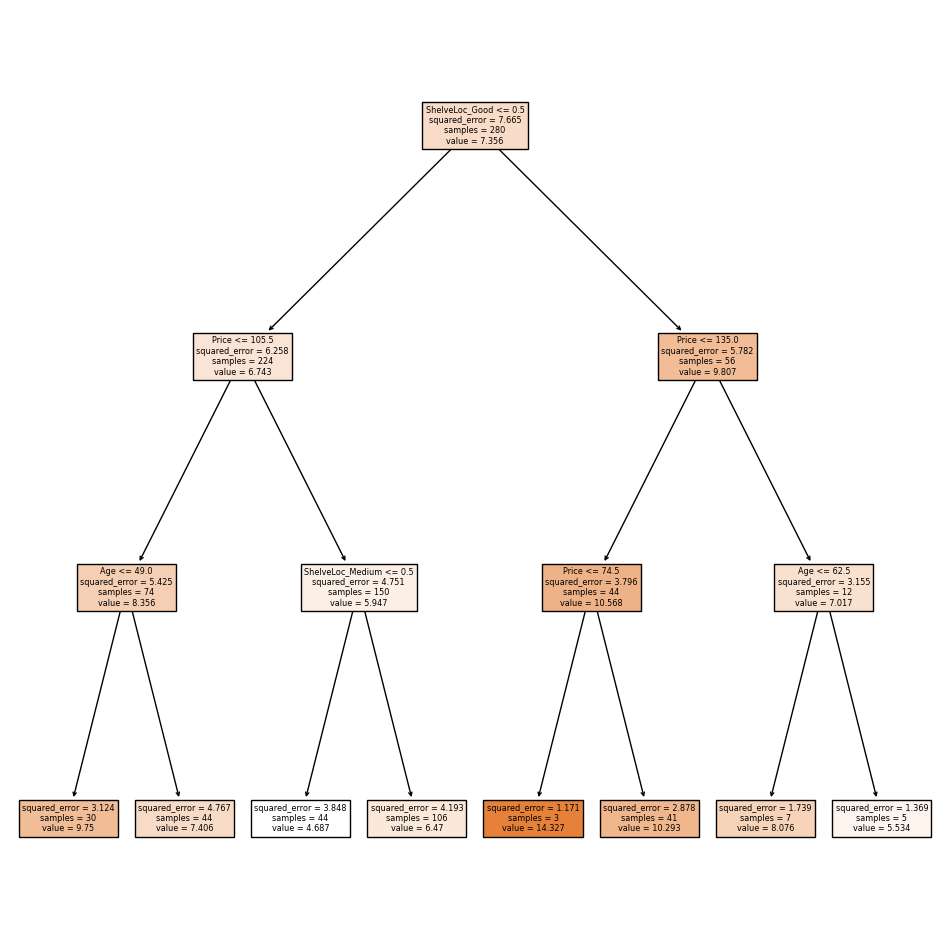

In [22]:
from sklearn.tree import (DecisionTreeClassifier as DTC,
                          DecisionTreeRegressor as DTR,
                          plot_tree,
                          export_text)
import matplotlib.pyplot as plt

tree = DTR(max_depth=3, random_state=1)
results = tree.fit(train_X,  train_y)
plt.figure().set_size_inches(12, 12)
plot_tree(results, feature_names=train_X.columns, filled=True);


In [29]:
# get mse
from sklearn.metrics import mean_squared_error
train_pred = results.predict(train_X)
train_mse = mean_squared_error(train_y, train_pred)
print(f"Train MSE: {train_mse:.4f}")
test_pred = results.predict(test_X)
test_mse = mean_squared_error(test_y, test_pred)
print(f"Test MSE: {test_mse:.4f}")

Train MSE: 3.7778
Test MSE: 4.8070


(c) Use cross-validation in order to determine the optimal level of tree complexity. Does pruning the tree improve the test MSE?

In [24]:
import sklearn.model_selection as ms

kfold = ms.KFold(n_splits=10, shuffle=True, random_state=42)

In [25]:
from sklearn.model_selection import GridSearchCV


grid_search = GridSearchCV(
    estimator=DTR(random_state=1),
    param_grid={'max_depth': np.arange(2, 20)},
    cv=kfold,
    scoring='accuracy', # Use an appropriate scoring metric
    n_jobs=-1 # Use all available processors
)

grid_search.fit(test_X, test_y)

print(f"Best cross-validation score: {grid_search.best_score_:.4f}")
print(f"Optimal parameters found: {grid_search.best_params_}")

# 8. Use the best estimator (the model with the optimal max_depth)
best_model = grid_search.best_estimator_
print(f"Optimal max_depth: {best_model.max_depth}")


Best cross-validation score: nan
Optimal parameters found: {'max_depth': 2}
Optimal max_depth: 2


c:\Users\benny\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_search.py:1051: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan]
  warnings.warn(


In [27]:
# check the proning tree
pruned_tree = DTR(max_depth=best_model.max_depth, random_state=1)
pruned_results = pruned_tree.fit(train_X, train_y)
print(export_text(pruned_results, feature_names=list(train_X.columns)))

|--- ShelveLoc_Good <= 0.50
|   |--- Price <= 105.50
|   |   |--- value: [8.36]
|   |--- Price >  105.50
|   |   |--- value: [5.95]
|--- ShelveLoc_Good >  0.50
|   |--- Price <= 135.00
|   |   |--- value: [10.57]
|   |--- Price >  135.00
|   |   |--- value: [7.02]



In [28]:
# compare the results
from sklearn.metrics import mean_squared_error
train_pred = best_model.predict(train_X)
test_pred = best_model.predict(test_X)
train_mse = mean_squared_error(train_y, train_pred)
test_mse = mean_squared_error(test_y, test_pred)
print(f"Train MSE: {train_mse:.4f}")
print(f"Test MSE: {test_mse:.4f}")


Train MSE: 5.4368
Test MSE: 3.9634


The pruning tree has smaller **MSE**.

(d) Use the bagging approach in order to analyze this data. What test MSE do you obtain? Use the feature_importance_ values to determine which variables are most important.

In [32]:
# apply bagging method
from sklearn.ensemble import BaggingRegressor
bagging_model = BaggingRegressor(
    n_estimators=100,
    random_state=1,
    n_jobs=-1
)
bagging_model.fit(train_X, train_y)
bagging_train_pred = bagging_model.predict(train_X)
bagging_test_pred = bagging_model.predict(test_X)
bagging_train_mse = mean_squared_error(train_y, bagging_train_pred)
bagging_test_mse = mean_squared_error(test_y, bagging_test_pred)
print(f"Bagging Train MSE: {bagging_train_mse:.4f}")
print(f"Bagging Test MSE: {bagging_test_mse:.4f}")


Bagging Train MSE: 0.3910
Bagging Test MSE: 2.5212


In [ ]:
# use feature importance to select features
importances = best_model.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': train_X.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)
print(feature_importance_df)

             Feature  Importance
7     ShelveLoc_Good    0.711334
4              Price    0.288666
0          CompPrice    0.000000
1             Income    0.000000
2        Advertising    0.000000
3         Population    0.000000
5                Age    0.000000
6          Education    0.000000
8   ShelveLoc_Medium    0.000000
9          Urban_Yes    0.000000
10            US_Yes    0.000000


This shows that the modt important feature is `ShelveLoc_Good`, which is a dummy variable column got from `ShelveLoc`.

(e) Use random forests to analyze this data. What test MSE do you obtain? Use the feature_importance_ values to determine which variables are most important. Describe the effect of m, the number of variables considered at each split, on the error rate obtained.

In [34]:
from sklearn.ensemble import RandomForestRegressor
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=1,
    n_jobs=-1
)
rf_model.fit(train_X, train_y)
rf_train_pred = rf_model.predict(train_X)
rf_test_pred = rf_model.predict(test_X)
rf_train_mse = mean_squared_error(train_y, rf_train_pred)
rf_test_mse = mean_squared_error(test_y, rf_test_pred)
print(f"Random Forest Train MSE: {rf_train_mse:.4f}")
print(f"Random Forest Test MSE: {rf_test_mse:.4f}")

Random Forest Train MSE: 0.3934
Random Forest Test MSE: 2.4868


In [35]:
# use feature importance to select features
importances = rf_model.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': train_X.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)
print(feature_importance_df)

             Feature  Importance
4              Price    0.319696
7     ShelveLoc_Good    0.197311
5                Age    0.121290
0          CompPrice    0.099193
2        Advertising    0.069684
8   ShelveLoc_Medium    0.054326
1             Income    0.052205
3         Population    0.040733
6          Education    0.029530
10            US_Yes    0.008108
9          Urban_Yes    0.007926


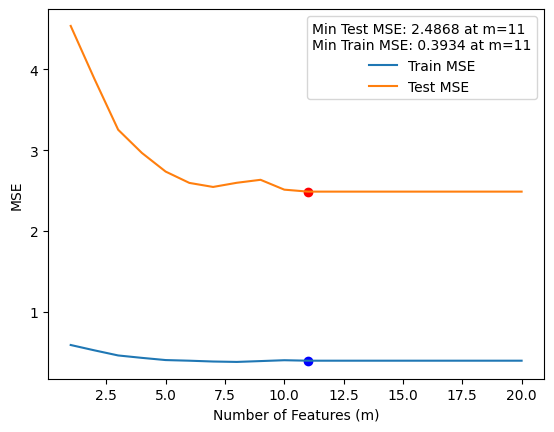

In [49]:
# find how the value m affect the model performance
m_values = range(1, 21)
train_mse_list = []
test_mse_list = []
for m in m_values:
    rf_model = RandomForestRegressor(
        n_estimators=100,
        max_features=m,
        random_state=1,
        n_jobs=-1
    )
    rf_model.fit(train_X, train_y)
    rf_train_pred = rf_model.predict(train_X)
    rf_test_pred = rf_model.predict(test_X)
    rf_train_mse = mean_squared_error(train_y, rf_train_pred)
    rf_test_mse = mean_squared_error(test_y, rf_test_pred)
    train_mse_list.append(rf_train_mse)
    test_mse_list.append(rf_test_mse)

plt.plot(m_values, train_mse_list, label='Train MSE')
plt.plot(m_values, test_mse_list, label='Test MSE')
# label the minimum test mse point
min_test_mse = min(test_mse_list)
min_m_test = m_values[test_mse_list.index(min_test_mse)]
plt.scatter(min_m_test, min_test_mse, color='red')
min_train_mse = train_mse_list[test_mse_list.index(min_test_mse)]
min_m_train = m_values[train_mse_list.index(min_train_mse)]
plt.scatter(min_m_train, min_train_mse, color='blue')
plt.xlabel('Number of Features (m)')
plt.ylabel('MSE')
plt.legend(
    title=f'Min Test MSE: {min_test_mse:.4f} at m={min_m_test}\nMin Train MSE: {min_train_mse:.4f} at m={min_m_train}'
)
plt.show()

(f) Now analyze the data using BART, and report your results.

In [62]:
from ISLP import bart
from ISLP.models import ModelSpec as ms
bart_model = bart.BART()
bart_model.fit(train_X, train_y)
bart_train_pred = bart_model.predict(train_X)
bart_test_pred = bart_model.predict(test_X)
bart_train_mse = mean_squared_error(train_y, bart_train_pred)
bart_test_mse = mean_squared_error(test_y, bart_test_pred)
print(f"BART Train MSE: {bart_train_mse:.4f}")
print(f"BART Test MSE: {bart_test_mse:.4f}")

BART Train MSE: 0.9174
BART Test MSE: 1.2986


In [66]:
# check feature importance for BART

model = ms(Carseats.columns.drop('Sales'), intercept=False)
Carseats_m = model.fit_transform(Carseats)
var_importance = pd.DataFrame(
    {'Importance':bart_model.variable_inclusion_.mean(0) / 100},
    index=Carseats_m.columns)
print(var_importance)

                  Importance
CompPrice              0.313
Income                 0.221
Advertising            0.316
Population             0.238
Price                  0.332
Age                    0.207
Education              0.262
ShelveLoc_Good         0.281
ShelveLoc_Medium       0.274
Urban_Yes              0.244
US_Yes                 0.255
